In [21]:
!pip install tensorflow


[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [25]:
df = pd.read_csv('HousingData.csv')

In [26]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [27]:
df.shape

(506, 14)

In [28]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [29]:
df.fillna(df.mean(), inplace=True)

In [30]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

<Axes: >

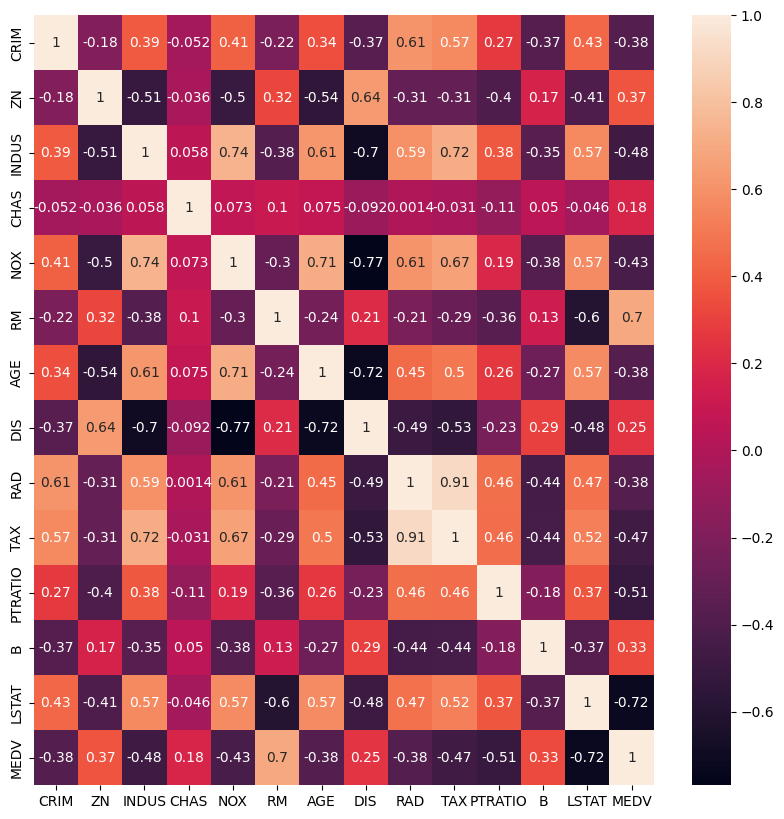

In [31]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot = True)

In [32]:
x = df.drop('MEDV', axis = 1)

In [33]:
y = df['MEDV']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [35]:
scaler = StandardScaler()

In [36]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [41]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(1)
])

In [42]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [43]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(
    x_train,
    y_train,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 572.0060 - mae: 21.8768 - val_loss: 465.0288 - val_mae: 19.8748
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 464.8621 - mae: 19.2714 - val_loss: 331.9202 - val_mae: 16.3112
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 292.9402 - mae: 14.6662 - val_loss: 156.7229 - val_mae: 10.5009
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 118.1882 - mae: 8.7467 - val_loss: 47.5536 - val_mae: 4.9392
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 69.8876 - mae: 6.4301 - val_loss: 39.4600 - val_mae: 4.6378
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 43.5568 - mae: 4.9636 - val_loss: 31.2442 - val_mae: 3.8852
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 32.1331 - mae: 4.1283 - val_loss: 28.3428 - val_mae: 3.7542
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 25.2094 - mae: 3.6719 - val_loss: 28.1367 - val_mae: 3.8820
Epoch 9/100
11/11 ━━━━━━━━━

In [45]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [46]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [47]:
print(f"Mean Squared Error : {mse}")
print(f"Root Mean Squared Error : {rmse}")
print(f"Mean Absolute Error : {mae}")
print(f"R2 Score : {r2}")

Mean Squared Error : 13.201557172401909
Root Mean Squared Error : 3.6333947173961034
Mean Absolute Error : 2.403306612313963
R2 Score : 0.8199798700751528


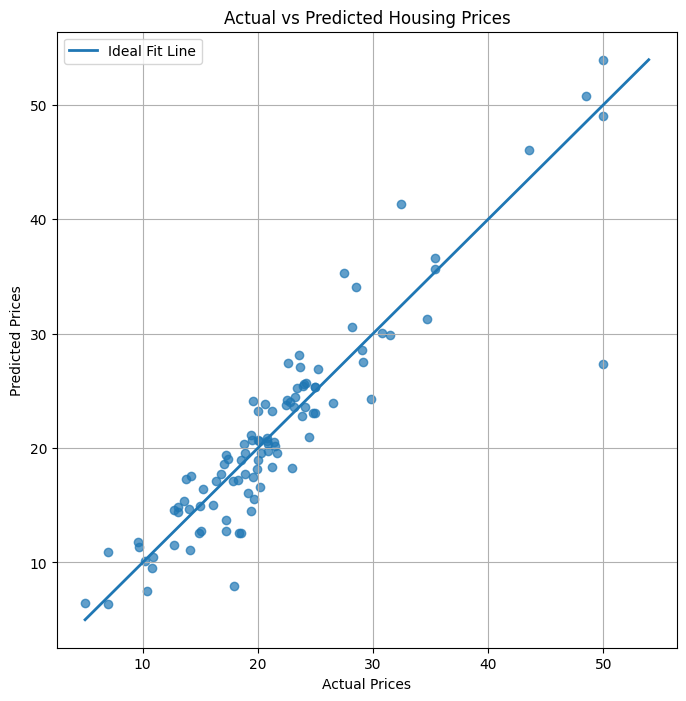

In [54]:
# Convert to 1D arrays
y_test_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred).flatten()

plt.figure(figsize=(8,8))

# Scatter plot
plt.scatter(y_test_flat, y_pred_flat, alpha=0.7)

# Ideal line
min_val = min(y_test_flat.min(), y_pred_flat.min())
max_val = max(y_test_flat.max(), y_pred_flat.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         linewidth=2,
         label='Ideal Fit Line')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
# Sample Predictions
for i in range(10):
    print(f"Actual Price: {y_test.iloc[i]:.2f} | Predicted Price: {y_pred[i][0]:.2f}")

Actual Price: 23.60 | Predicted Price: 28.14
Actual Price: 32.40 | Predicted Price: 41.37
Actual Price: 13.60 | Predicted Price: 15.38
Actual Price: 22.80 | Predicted Price: 24.06
Actual Price: 16.10 | Predicted Price: 15.02
Actual Price: 20.00 | Predicted Price: 20.74
Actual Price: 17.80 | Predicted Price: 17.11
Actual Price: 14.00 | Predicted Price: 14.67
Actual Price: 19.60 | Predicted Price: 24.09
Actual Price: 16.80 | Predicted Price: 17.77
